In [ ]:
import numpy as np
from units.generate import load_model
from units.data import load_dataset_from_args
import os,torch
from rdkit.Chem.Draw import IPythonConsole
from torch_geometric.data import DataLoader
from rdkit import Chem
from qcbot.utils import symbol_pos_to_xyz_file
pt = Chem.GetPeriodicTable()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.molSize = 300, 300
root_path = os.path.dirname(os.path.abspath('.'))
os.chdir(root_path)

/opt/conda/lib/python3.11/site-packages/units/hiegnn/dependencies/wigner.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd = torch.load(os.path.join(os.path.dirname(__

In [2]:
data_idx = 2649
model_path = "./units/model_path/da_hiegnn"
ckpt_file = "best_full_model.pth"
args,model = load_model(model_path,ckpt_file)
ts_dataset,ts_graph_dataset = load_dataset_from_args(args,only_test=False,shuffle=False)
raw_ts_dataset = np.load("./dataset/da_reaction_0.npy",allow_pickle=True)

alphas2 [9.99990000e-01 9.99988000e-01 9.99982000e-01 ... 2.59676966e-05
 1.39959211e-05 1.00039959e-05]
gamma [-11.51291546 -11.33059532 -10.92513058 ...  10.55863126  11.17673063
  11.51251595]


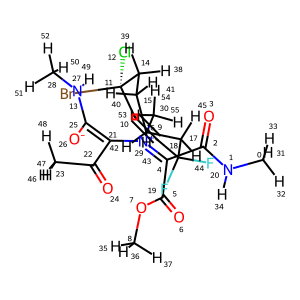

In [11]:
raw_ts_dataset[data_idx][-3]

In [19]:
raw_ts_dataset[data_idx][2]

[tensor([[1, 4, 3, 2, 2, 0, 4, 0, 2, 0],
         [2, 3, 3, 1, 2, 0, 3, 0, 2, 0],
         [1, 3, 3, 1, 2, 0, 4, 0, 2, 0],
         [3, 1, 3, 1, 2, 0, 2, 0, 2, 0],
         [1, 3, 3, 1, 2, 0, 4, 0, 2, 0],
         [1, 3, 3, 1, 2, 0, 4, 0, 2, 0],
         [3, 1, 3, 1, 2, 0, 2, 0, 2, 0],
         [3, 2, 3, 1, 2, 0, 2, 0, 2, 0],
         [1, 4, 3, 2, 2, 0, 4, 0, 2, 0],
         [1, 2, 3, 0, 2, 0, 4, 0, 2, 0],
         [1, 2, 3, 0, 2, 0, 4, 0, 2, 0],
         [1, 4, 3, 2, 0, 0, 4, 0, 1, 0],
         [8, 1, 3, 2, 2, 0, 1, 0, 2, 0],
         [9, 1, 3, 2, 2, 0, 1, 0, 2, 0],
         [1, 4, 3, 2, 2, 0, 4, 0, 2, 0],
         [1, 4, 3, 2, 2, 0, 4, 0, 2, 0],
         [1, 4, 3, 2, 2, 0, 4, 0, 2, 0],
         [1, 4, 3, 2, 2, 0, 4, 0, 2, 0],
         [1, 4, 3, 2, 2, 0, 4, 0, 2, 0],
         [5, 1, 3, 2, 2, 0, 1, 0, 2, 0],
         [5, 1, 3, 2, 2, 0, 1, 0, 2, 0],
         [1, 3, 3, 1, 2, 0, 4, 0, 2, 0],
         [1, 3, 3, 1, 2, 0, 4, 0, 2, 0],
         [1, 4, 3, 2, 2, 0, 4, 0, 2, 0],
         [3, 1, 

In [12]:
sel_dataset = ts_dataset[[data_idx]*10]
dataloader = DataLoader(sel_dataset, batch_size=min(8,len(sel_dataset)), shuffle=False, num_workers=args.num_workers)
tot_pred_final = []
for data in dataloader:
    data = data.to(device)
    x_traj,mol_atoms,node_mask = model.sample_traj(data,fix_noise=False,resample=False)
    pred_final = x_traj[-1]
    tot_pred_final.append(pred_final)

1000it [05:09,  3.23it/s]
1000it [01:25, 11.68it/s]


In [13]:
os.makedirs("./notebook/cycloaddition",exist_ok=True)
i = 0
for idx,pred_pos_lst in enumerate(tot_pred_final):
    for _,pred_pos in enumerate(pred_pos_lst):
        atoms = sel_dataset[0].mol_atoms
        symbols = [pt.GetElementSymbol(int(a)) for a in atoms]
        symbol_pos_to_xyz_file(symbols,pred_pos,f"./notebook/cycloaddition/gen_{i}.xyz")
        i += 1